# RNA Velocity PCA Manifold Fitting

Run the merged manifold fitter on the four RNA-velocity benchmark datasets and compare before/after in PCA space. Each dataset gets a three-panel plot: before, after, and movement path.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

repo_root = Path.cwd()
if not (repo_root / "scripts").exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root))

from scripts.velocity_manifold_fitter import VelocityManifoldFitter

out_dir = repo_root / "outputs/rna_velocity"
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
DATASETS = {
    "cell_cycle": {
        "X": repo_root / "data/cell_cycle/X_cc.npy",
        "V": repo_root / "data/cell_cycle/V_cc.npy",
        "color": repo_root / "data/cell_cycle/color_cell_cycle_relativePos.npy",
        "max_cells": None,
    },
    "pancreas": {
        "X": repo_root / "data/pancreas/X_pca.npy",
        "V": repo_root / "data/pancreas/V_pca_stochastic.npy",
        "color": repo_root / "data/pancreas/color_clusters.npy",
        "max_cells": None,
    },
    "dentate_gyrus": {
        "X": repo_root / "data/dentate_gyrus/X_pca.npy",
        "V": repo_root / "data/dentate_gyrus/V_pca_stochastic.npy",
        "color": repo_root / "data/dentate_gyrus/color_clusters.npy",
        "max_cells": None,
    },
    "larry": {
        "X": repo_root / "data/larry/X_raw.npy",
        "V": repo_root / "data/larry/V_raw.npy",
        "color": repo_root / "data/larry/color_state.npy",
        "max_cells": 1000,
    },
}

dataset_order = ["cell_cycle", "pancreas", "dentate_gyrus", "larry"]
rng = np.random.default_rng(0)


In [3]:
def load_dataset(name, seed=0):
    spec = DATASETS[name]
    X = np.asarray(np.load(spec["X"], allow_pickle=True), dtype=float)
    V = np.asarray(np.load(spec["V"], allow_pickle=True), dtype=float)
    color = np.load(spec["color"], allow_pickle=True)

    max_cells = spec.get("max_cells")
    if max_cells is not None and X.shape[0] > max_cells:
        local_rng = np.random.default_rng(seed)
        idx = np.sort(local_rng.choice(X.shape[0], size=max_cells, replace=False))
        X = X[idx]
        V = V[idx]
        color = color[idx]
    else:
        idx = np.arange(X.shape[0])

    return X, V, color, idx

def color_kwargs(values):
    values = np.asarray(values)
    if np.issubdtype(values.dtype, np.number):
        return {"c": values, "cmap": "viridis"}, None

    labels = np.unique(values)
    cmap = plt.get_cmap("tab10" if len(labels) <= 10 else "tab20")
    lookup = {label: cmap(i % cmap.N) for i, label in enumerate(labels)}
    colors = np.array([lookup[value] for value in values])
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=lookup[label], markersize=6, label=str(label))
        for label in labels
    ]
    return {"c": colors}, handles


def set_shared_limits(axes, *arrays, pad_frac=0.06):
    stacked = np.vstack(arrays)
    mins = stacked.min(axis=0)
    maxs = stacked.max(axis=0)
    span = np.maximum(maxs - mins, 1e-12)
    pad = pad_frac * span
    for ax in axes:
        ax.set_xlim(mins[0] - pad[0], maxs[0] + pad[0])
        ax.set_ylim(mins[1] - pad[1], maxs[1] + pad[1])
        ax.set_aspect("equal", adjustable="box")


def choose_quiver_idx(n, max_arrows=450, seed=0):
    local_rng = np.random.default_rng(seed)
    size = min(max_arrows, n)
    return local_rng.choice(n, size=size, replace=False)


In [4]:
def run_and_plot_dataset(name, seed=0):
    X, V, color, source_idx = load_dataset(name, seed=seed)
    print(f"{name}: fitting {X.shape[0]} cells x {X.shape[1]} features")

    fitter = VelocityManifoldFitter(X, V, random_state=seed)
    out = fitter.fit(return_dict=True)
    X_model = fitter.Y
    V_model = fitter.W
    X_fit = out["X"]
    V_fit = out["V"]

    pca = PCA(n_components=2)
    X_pc = pca.fit_transform(X_model)
    X_fit_pc = pca.transform(X_fit)
    V_pc = V_model @ pca.components_.T
    V_fit_pc = V_fit @ pca.components_.T

    quiver_idx = choose_quiver_idx(X_model.shape[0], seed=seed)
    scatter_kwargs, legend_handles = color_kwargs(color)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

    axes[0].scatter(X_pc[:, 0], X_pc[:, 1], s=8, alpha=0.82, **scatter_kwargs)
    axes[0].quiver(
        X_pc[quiver_idx, 0], X_pc[quiver_idx, 1],
        V_pc[quiver_idx, 0], V_pc[quiver_idx, 1],
        color="black", alpha=0.55, width=0.003,
    )
    axes[0].set_title("Before manifold fitting")

    axes[1].scatter(X_fit_pc[:, 0], X_fit_pc[:, 1], s=8, alpha=0.82, **scatter_kwargs)
    axes[1].quiver(
        X_fit_pc[quiver_idx, 0], X_fit_pc[quiver_idx, 1],
        V_fit_pc[quiver_idx, 0], V_fit_pc[quiver_idx, 1],
        color="black", alpha=0.55, width=0.003,
    )
    axes[1].set_title("After manifold fitting")

    for j in quiver_idx:
        axes[2].plot(
            [X_pc[j, 0], X_fit_pc[j, 0]],
            [X_pc[j, 1], X_fit_pc[j, 1]],
            color="0.25", alpha=0.18, linewidth=0.7,
        )
    axes[2].scatter(X_pc[quiver_idx, 0], X_pc[quiver_idx, 1], s=10, color="0.70", alpha=0.7, label="before")
    axes[2].scatter(X_fit_pc[quiver_idx, 0], X_fit_pc[quiver_idx, 1], s=13, color="crimson", alpha=0.75, label="after")
    axes[2].set_title("Movement path in PCA space")
    axes[2].legend(frameon=False, loc="best")

    for ax in axes:
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

    set_shared_limits(axes, X_pc, X_fit_pc)

    if legend_handles is not None:
        axes[1].legend(handles=legend_handles, title="label", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    explained = pca.explained_variance_ratio_
    fig.suptitle(
        f"{name}: PCA before/after manifold fitting | PC1={explained[0]:.3f}, PC2={explained[1]:.3f}",
        y=1.04,
    )

    fig_path = out_dir / f"{name}_pca_before_after_path.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")

    metrics = {
        "dataset": name,
        "n_cells_fit": X_model.shape[0],
        "n_features_input": X.shape[1],
        "n_features_fit": X_model.shape[1],
        "pc1_var": float(explained[0]),
        "pc2_var": float(explained[1]),
        "mean_step_norm_last": out["history"][-1]["mean_step_norm"],
        "mean_pca_displacement": float(np.mean(np.linalg.norm(X_fit_pc - X_pc, axis=1))),
        "figure": str(fig_path),
    }
    return metrics, fig


cell_cycle: fitting 2793 cells x 33 features


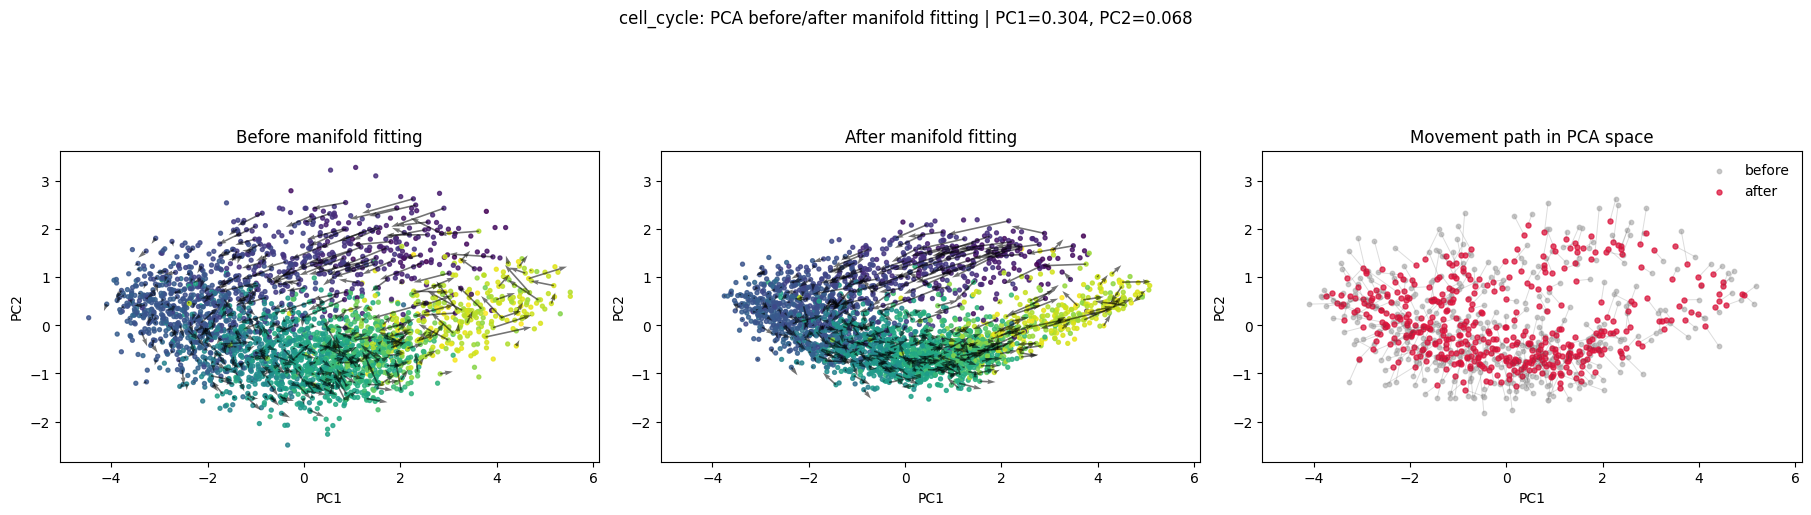

pancreas: fitting 3696 cells x 50 features


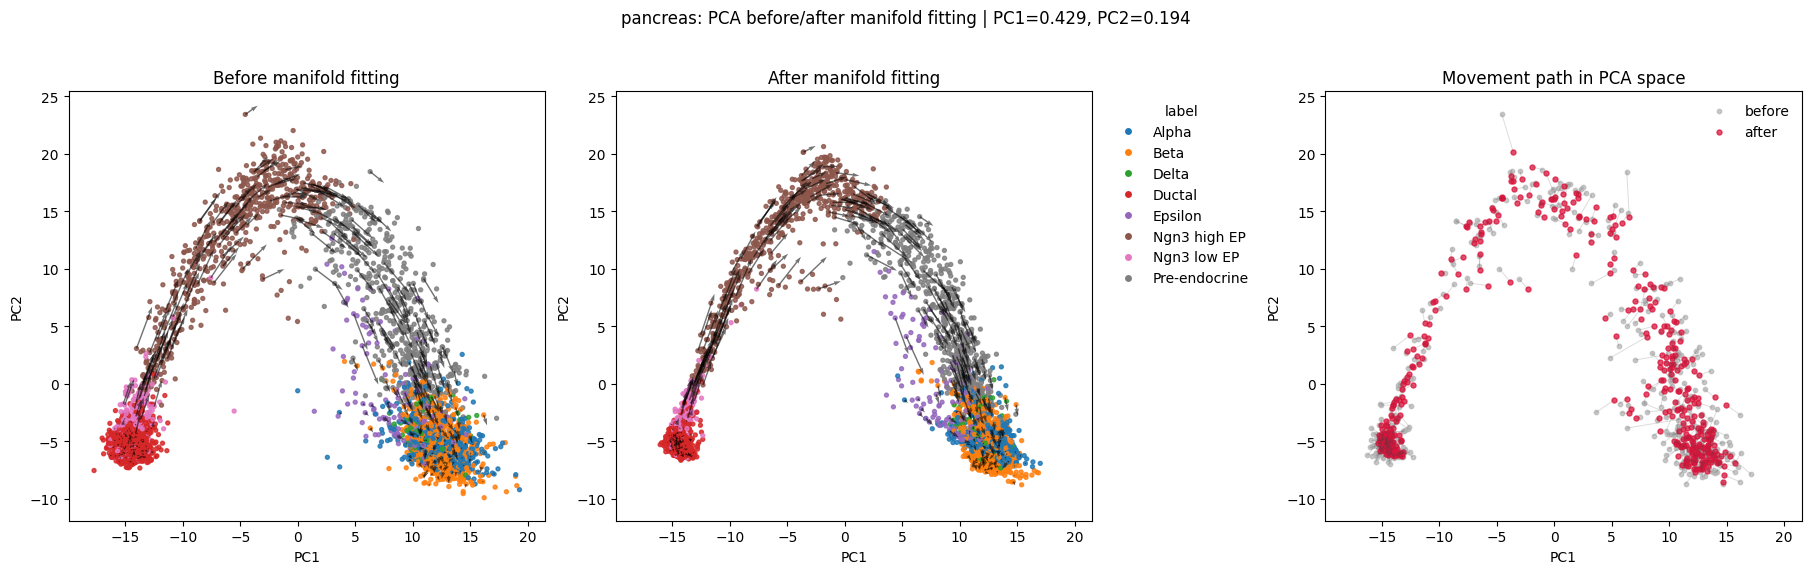

dentate_gyrus: fitting 2930 cells x 50 features


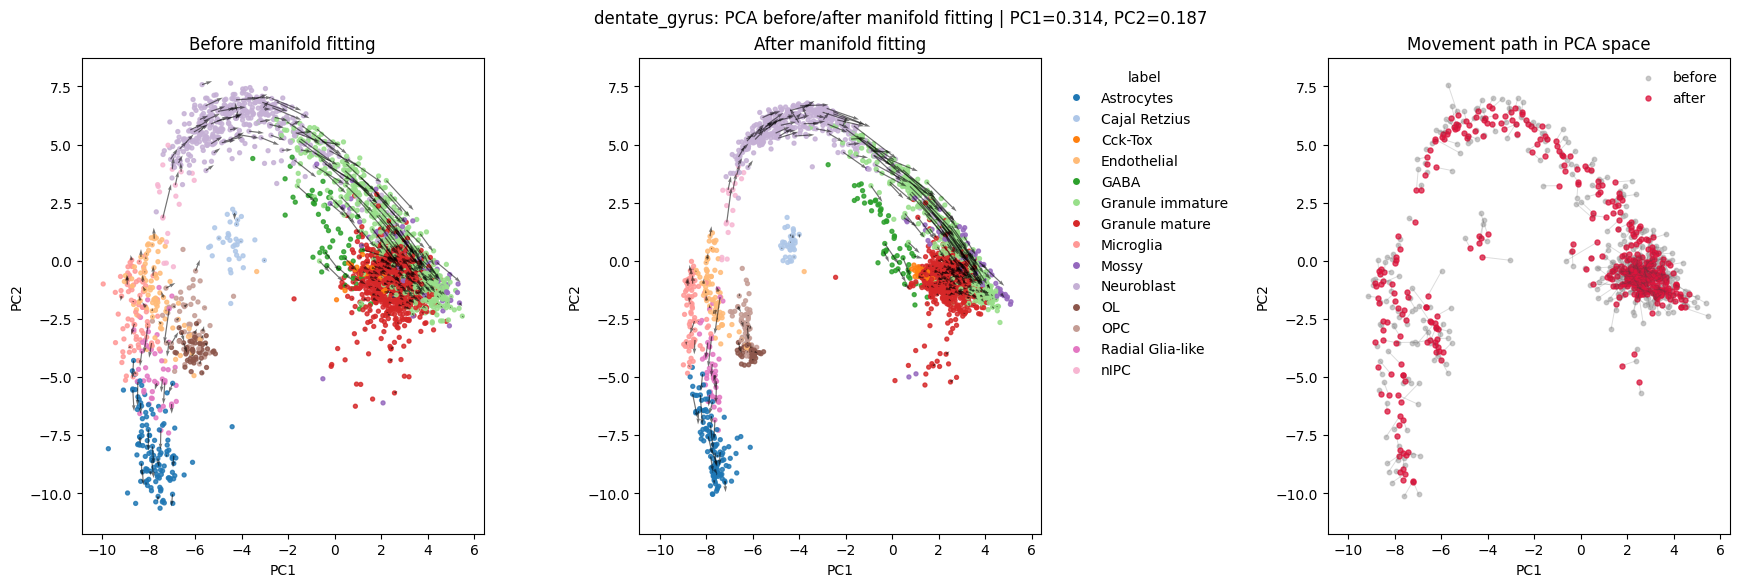

larry: fitting 1000 cells x 2000 features


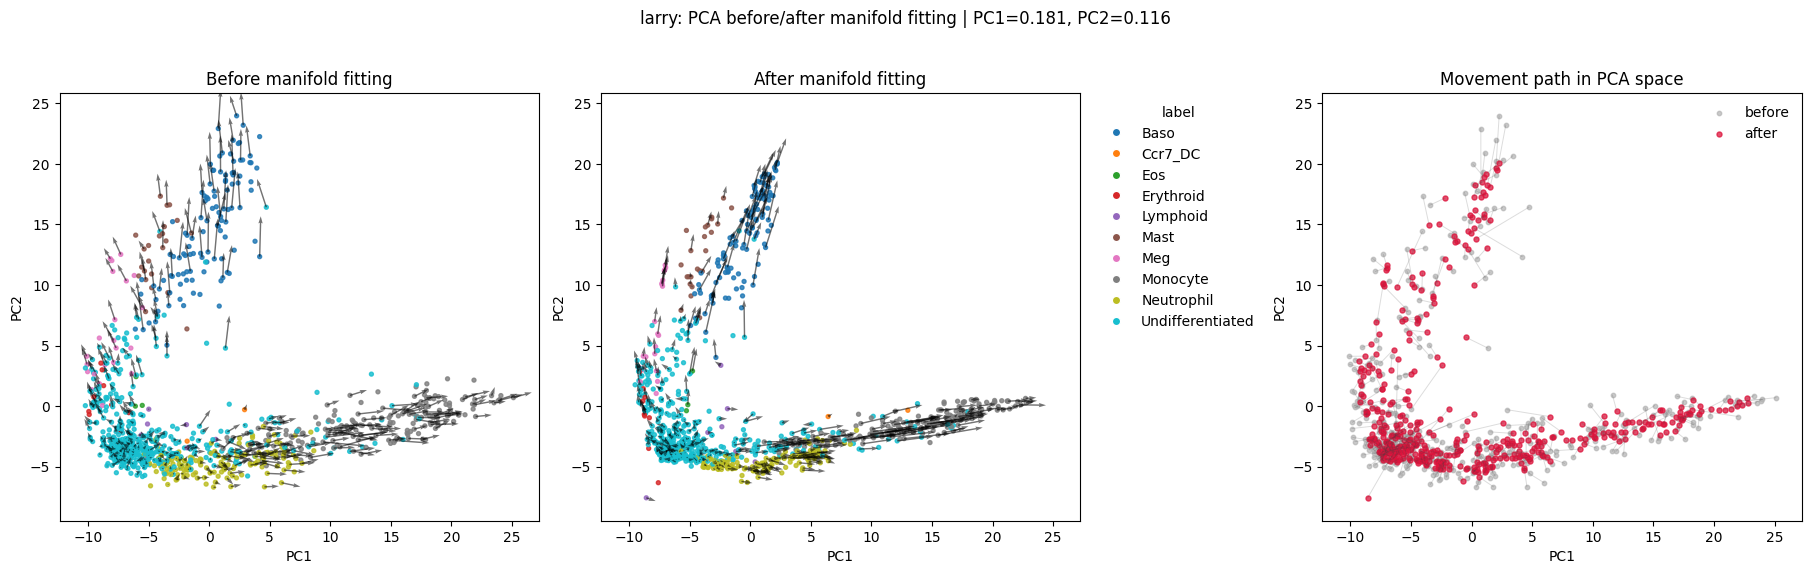

,dataset,n_cells_fit,n_features_input,n_features_fit,pc1_var,pc2_var,mean_step_norm_last,mean_pca_displacement,figure
0,cell_cycle,2793,33,30,0.304345,0.067675,0.181831,0.332062,/Users/jh/Projects/ManfitVelo/outputs/rna_velo...
1,pancreas,3696,50,30,0.429340,0.193788,0.505483,0.883366,/Users/jh/Projects/ManfitVelo/outputs/rna_velo...
2,dentate_gyrus,2930,50,30,0.313986,0.187261,0.245976,0.454799,/Users/jh/Projects/ManfitVelo/outputs/rna_velo...
3,larry,1000,2000,30,0.181094,0.115583,0.871428,1.175768,/Users/jh/Projects/ManfitVelo/outputs/rna_velo...


In [5]:
all_metrics = []
figures = {}

for name in dataset_order:
    metrics, fig = run_and_plot_dataset(name, seed=0)
    all_metrics.append(metrics)
    figures[name] = fig
    display(fig)
    plt.close(fig)

metrics_df = pd.DataFrame(all_metrics)
metrics_path = out_dir / "rna_velocity_pca_manifold_fit_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
metrics_df